Seed set to 1048596


Using device: Apple Metal (MPS)
Epoch 10, train_loss: 0.0523, val_loss: 0.0383
Epoch 20, train_loss: 0.0247, val_loss: 0.0238
Epoch 30, train_loss: 0.0163, val_loss: 0.0235
Epoch 40, train_loss: 0.0144, val_loss: 0.0220
Epoch 50, train_loss: 0.0119, val_loss: 0.0232
Epoch 60, train_loss: 0.0108, val_loss: 0.0238
Epoch 70, train_loss: 0.0099, val_loss: 0.0207
Epoch 80, train_loss: 0.0098, val_loss: 0.0200
Epoch 90, train_loss: 0.0087, val_loss: 0.0190
Epoch 100, train_loss: 0.0082, val_loss: 0.0211
Epoch 110, train_loss: 0.0076, val_loss: 0.0196
Epoch 120, train_loss: 0.0072, val_loss: 0.0160
Epoch 130, train_loss: 0.0067, val_loss: 0.0217
Epoch 140, train_loss: 0.0061, val_loss: 0.0250
Epoch 150, train_loss: 0.0060, val_loss: 0.0178
Epoch 160, train_loss: 0.0059, val_loss: 0.0173
Epoch 170, train_loss: 0.0051, val_loss: 0.0192
Epoch 180, train_loss: 0.0044, val_loss: 0.0185
Epoch 190, train_loss: 0.0042, val_loss: 0.0210
Epoch 200, train_loss: 0.0040, val_loss: 0.0204
Epoch 210, train_

Seed set to 1048596


Epoch 290, train_loss: 0.0022, val_loss: 0.0172
Early stopping at epoch 291 (best_val_loss=0.0132)
MSE: 40285.15
RMSE: 200.71
MAE: 173.58
MAPE: 10.25%
R²: -2.2741
Using device: Apple Metal (MPS)
Epoch 10, train_loss: 0.0538, val_loss: 0.0208
Epoch 20, train_loss: 0.0257, val_loss: 0.0088
Epoch 30, train_loss: 0.0178, val_loss: 0.0137
Epoch 40, train_loss: 0.0143, val_loss: 0.0111
Epoch 50, train_loss: 0.0130, val_loss: 0.0072
Epoch 60, train_loss: 0.0111, val_loss: 0.0106
Epoch 70, train_loss: 0.0105, val_loss: 0.0115
Epoch 80, train_loss: 0.0102, val_loss: 0.0128
Epoch 90, train_loss: 0.0092, val_loss: 0.0090
Epoch 100, train_loss: 0.0086, val_loss: 0.0052
Epoch 110, train_loss: 0.0076, val_loss: 0.0092
Epoch 120, train_loss: 0.0082, val_loss: 0.0091
Epoch 130, train_loss: 0.0076, val_loss: 0.0108
Epoch 140, train_loss: 0.0069, val_loss: 0.0081
Epoch 150, train_loss: 0.0065, val_loss: 0.0091
Epoch 160, train_loss: 0.0060, val_loss: 0.0093
Epoch 170, train_loss: 0.0054, val_loss: 0.008

Seed set to 1048596


Epoch 300, train_loss: 0.0024, val_loss: 0.0116
Early stopping at epoch 300 (best_val_loss=0.0052)
MSE: 208590.83
RMSE: 456.72
MAE: 334.33
MAPE: 14.91%
R²: -0.4765
Using device: Apple Metal (MPS)
Epoch 10, train_loss: 0.0605, val_loss: 0.0087
Epoch 20, train_loss: 0.0307, val_loss: 0.0028
Epoch 30, train_loss: 0.0206, val_loss: 0.0027
Epoch 40, train_loss: 0.0164, val_loss: 0.0026
Epoch 50, train_loss: 0.0155, val_loss: 0.0033
Epoch 60, train_loss: 0.0128, val_loss: 0.0048
Epoch 70, train_loss: 0.0123, val_loss: 0.0023
Epoch 80, train_loss: 0.0112, val_loss: 0.0034
Epoch 90, train_loss: 0.0107, val_loss: 0.0018
Epoch 100, train_loss: 0.0096, val_loss: 0.0015
Epoch 110, train_loss: 0.0095, val_loss: 0.0016
Epoch 120, train_loss: 0.0086, val_loss: 0.0019
Epoch 130, train_loss: 0.0089, val_loss: 0.0011
Epoch 140, train_loss: 0.0081, val_loss: 0.0023
Epoch 150, train_loss: 0.0077, val_loss: 0.0041
Epoch 160, train_loss: 0.0079, val_loss: 0.0024
Epoch 170, train_loss: 0.0072, val_loss: 0.00

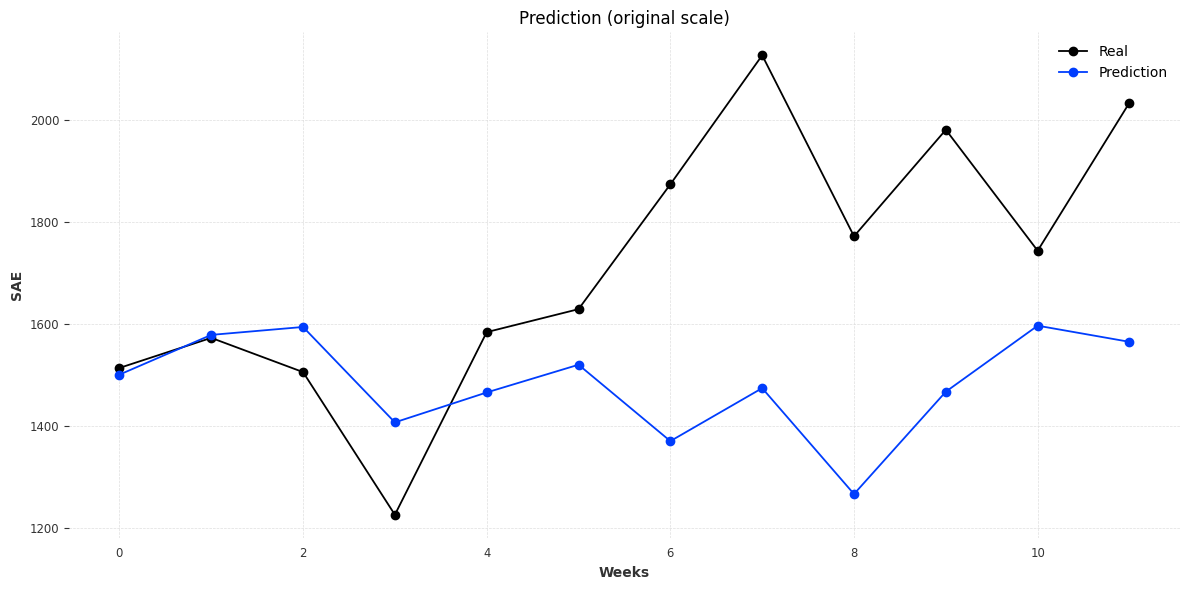

In [3]:
import warnings
import sys
sys.path.append('/Users/zilikons/code/zilikons/jp/shippingNN/')
warnings.filterwarnings("ignore")
import pytorch_lightning as pl
import pandas as pd
import torch
import numpy as np
from datetime import datetime
from functions import error_metrics, run_transformer_xai, get_attention_maps, run_transformer_with_for_xai
from functions import prettify, rename_specific
import os

import matplotlib.pyplot as plt



# torch.set_float32_matmul_precision("high")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# Configurar dispositivo
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Load data
df = pd.read_csv("../weekly_chile_data.csv")
df["FECHA"] = pd.to_datetime(df["FECHA"])
tmp = df.copy().sort_values("FECHA")

# BEST FE 4
test_size = 4
target_col = "FE"
window_size = 42
batch_size = 128
d_model = 64
n_head = 2
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 0.000340605
dropout = 0.069862972
weight_decay = 0.000187754


#BEST NAE 4

test_size = 4
target_col = "NAE"
window_size = 51
batch_size = 32
d_model = 64
n_head = 4
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 0.000397956
dropout = 0.223329688
weight_decay = 0.000103901

#BEST NAW 4
test_size = 4
target_col = "NAW"
window_size = 41
batch_size = 64
d_model = 128
n_head = 4
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 6.47E-05
dropout = 0.121422183
weight_decay = 6.10E-06



# BEST NE 4
test_size = 4
target_col = "NE"
window_size = 30
batch_size = 128
d_model = 32
n_head = 8
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 9.28E-05
dropout = 0.483863325
weight_decay = 0.000197146

# BEST SE 4
test_size = 4
target_col = "SE"
window_size = 36
batch_size = 32
d_model = 256
n_head = 4
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 0.000555638
dropout = 0.312582405
weight_decay = 0.000179268

# BEST SAW 4
test_size = 4
target_col = "SAW"
window_size = 32
batch_size = 128
d_model = 32
n_head = 2
num_layers = 2  # lstm layers
epoch_number = 2000
lr = 0.000147759
dropout = 0.424560519
weight_decay = 8.66E-05

# BEST SAE 4
test_size = 4
target_col = "SAE"
window_size = 32
batch_size = 32
d_model = 128
n_head = 2
num_layers = 4 # lstm layers
epoch_number = 2000
lr = 0.000482691
dropout = 0.517106545
weight_decay = 7.75E-06



# BEST FE 12
test_size = 12
target_col = "FE"
window_size = 28
batch_size = 32
d_model = 128
n_head = 2
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 0.001
dropout = 0.332641601
weight_decay = 0.001


# BEST NAE 12
test_size = 12
target_col = "NAE"
window_size = 26
batch_size = 32
d_model = 64
n_head = 2
num_layers = 4  # lstm layers
lr = 0.000187546
dropout = 0.273919743
weight_decay = 7.55E-06


# BEST NAW 12
test_size = 12
target_col = "NAW"
window_size = 51
batch_size = 128
d_model = 256
n_head = 8
num_layers = 4  # lstm layers
lr = 0.00029803
dropout = 0.165152428
weight_decay = 5.62E-06


# BEST NE 12
test_size = 12
target_col = "NE"
window_size = 47
batch_size = 32
d_model = 64
n_head = 2
num_layers = 4  # lstm layers
lr = 0.0004815
dropout = 0.318221159
weight_decay = 4.00E-05


#BEST SE 12
test_size = 12
target_col = "SE"
window_size = 50
batch_size = 32
d_model = 64
n_head = 8
num_layers = 4  # lstm layers
lr = 0.000427606
dropout = 0.444859662
weight_decay = 1.50E-05

# BEST SAW 12
test_size = 12
target_col = "SAW"
window_size = 49
batch_size = 128
d_model = 256
n_head = 4
num_layers = 4  # lstm layers
lr = 0.000551659
dropout = 0.426466938
weight_decay = 6.90E-05

# BEST SAE 12
test_size = 12
target_col = "SAE"
window_size = 45
batch_size = 64
d_model = 256
n_head = 8
num_layers = 3  # lstm layers
lr = 0.000496422
dropout = 0.506098107
weight_decay = 1.00E-06

#==============================

# General parameters
seed = 1048596
patience = 200
min_delta = 1e-5
epoch_number = 2000

tmp = df.copy().sort_values("FECHA")



avg_mae, avg_mape, avg_mse, avg_rmse, avg_r2, avg_epochs_ran, sd, out, y_true, y_pred = run_transformer_with_for_xai(
    tmp, target_col, window_size, test_size, batch_size, d_model, n_head,
     num_layers, epoch_number, lr, dropout,
     device, seed, optimizer_type='adam', weight_decay=weight_decay, early_stop=True,
     patience=patience,
     min_delta=min_delta,
     n_runs=3,
)

mae, mape, mse, rmse, r2 = error_metrics(y_true, y_pred)

plt.figure(figsize=(12, 6))
plt.plot(y_true, marker="o", label="Real")
plt.plot(y_pred, marker="o", label="Prediction")
plt.title("Prediction (original scale)")
plt.xlabel("Weeks")
plt.ylabel(target_col)
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig(f"plots/transformers_prediction_{target_col}_{test_size}.png", dpi=200)

H = test_size  # 4
HORIZON_TO_EXPLAIN = H - 1  # last step (3). Change to 0..3 if you want.

In [4]:
# LIME _____________________________________________-

import numpy as np
from lime.lime_tabular import LimeTabularExplainer
from darts import TimeSeries

model = out[0]
train_ts = out[1]
val_ts = out[2]
scaler_y = out[3]
scaler_cov = out[4]
feature_cols = out[6]

# AUDIT FIX: make sure the model is in inference mode for XAI (dropout OFF)
model.to(device)
model.eval()
torch.set_grad_enabled(False)

# Optional guard: if you truly intend a covariates-only model, the target must NOT be in feature_cols
if target_col in feature_cols:
    print(f"⚠️ WARNING: target_col '{target_col}' is present inside feature_cols. This leaks the target into the model inputs and will invalidate feature importance.")


# Ensure datetime (CRITICAL)
df["FECHA"] = pd.to_datetime(df["FECHA"])

# Rebuild full target series and covariates
full_series = TimeSeries.from_dataframe(df, "FECHA", target_col)
full_cov = TimeSeries.from_dataframe(df, "FECHA", feature_cols)

series_scaled = scaler_y.transform(full_series)
cov_scaled = scaler_cov.transform(full_cov)

F = 1 + len(feature_cols)

# last forecast point
last_idx = len(df) - 1
start_hist = last_idx - test_size + 1 - window_size
assert start_hist >= 0

start_time = df["FECHA"].iloc[start_hist]
end_time = df["FECHA"].iloc[start_hist + window_size - 1]

hist_target = series_scaled.slice(start_time, end_time)
hist_cov = cov_scaled.slice(start_time, end_time)

y_hist_np = hist_target.values(copy=True)
cov_hist_np = hist_cov.values(copy=True)

hist_full_np = np.concatenate([y_hist_np, cov_hist_np], axis=1)
x0 = hist_full_np.flatten()

# Feature names
feat_names = []
cols_all = [target_col] + feature_cols
for t in range(window_size):
    lag = window_size - 1 - t
    for c in cols_all:
        feat_names.append(f"{c}_t-{lag}")

# LIME background
X_lime = np.tile(x0, (200, 1))
X_lime += np.random.normal(scale=0.01, size=X_lime.shape)

explainer = LimeTabularExplainer(
    X_lime,
    feature_names=feat_names,
    mode="regression",
    verbose=False,
    discretize_continuous=False,
)



def _inverse_scale_y(y_scaled: np.ndarray) -> np.ndarray:
    """Inverse-scale a 1D array of scaled forecasts to original scale.
    Supports your custom min-max scaler (vmin/vmax). Falls back to scaler_y.inverse_transform if available.
    """
    y_scaled = np.asarray(y_scaled).reshape(-1)

    # Custom min-max scaler (as used in your code)
    if hasattr(scaler_y, "vmin") and hasattr(scaler_y, "vmax"):
        vmin = np.asarray(scaler_y.vmin).reshape(-1)[0]
        vmax = np.asarray(scaler_y.vmax).reshape(-1)[0]
        return y_scaled * (vmax - vmin) + vmin

    # Fallback: Darts / sklearn-style inverse_transform
    if hasattr(scaler_y, "inverse_transform"):
        try:
            from darts import TimeSeries
            ts = TimeSeries.from_values(y_scaled.reshape(-1, 1))
            inv = scaler_y.inverse_transform(ts).values(copy=False).reshape(-1)
            return inv
        except Exception as e:
            raise RuntimeError(f"Could not inverse_transform with scaler_y: {e}") from e

    raise RuntimeError("Unknown scaler_y type: cannot inverse-scale predictions.")


def predict_fn(flat_X):
    """LIME predict_fn: returns a 1D array of predictions for the selected horizon."""
    assert 0 <= HORIZON_TO_EXPLAIN < H, f"HORIZON_TO_EXPLAIN={HORIZON_TO_EXPLAIN} out of range [0,{H-1}]"

    flat_X = np.asarray(flat_X)
    preds = np.zeros(flat_X.shape[0], dtype=float)

    for i in range(flat_X.shape[0]):
        arr = flat_X[i].reshape(window_size, F)

        # Transformer ONLY uses covariates (match your training pipeline)
        cov_win = arr[:, 1:]  # (T, n_cov)

        X = torch.tensor(cov_win, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            y_hat_scaled = model(X).detach().cpu().numpy().reshape(-1)  # (H,)

        y_hat = _inverse_scale_y(y_hat_scaled)
        preds[i] = float(np.asarray(y_hat[HORIZON_TO_EXPLAIN]).squeeze())

    return preds

Top mean LIME contributions:
Csi300 Volume T-0             0.661070
Freight Per TEU T-0           0.549064
Clp Price T-0                 0.506780
Brent Oil Price T-0           0.479033
Yang Ming Volume T-0          0.420576
South America West T-0        0.349323
Total TEU Vietnam T-0         0.244301
Total TEU Belgica T-0         0.229078
North America East T-0        0.211124
Total TEU Cma Cgm T-0         0.157545
NGF Natural Gas Volume T-0    0.141745
Total TEU Maersk T-0          0.141584
Time Idx T-0                  0.135957
FE T-2                        0.105343
Total TEU Francia T-0        -0.145557
dtype: float64

Top unstable features (std):
csi300_volume_t-0              0.045702
SUM_TEU_VIETNAM_t-0            0.043396
SUM_TEU_CMA CGM_t-0            0.042009
ngfnaturalgas_volume_t-0       0.040906
FE_t-2                         0.039010
SUM_TEU_other_companies_t-0    0.038525
hapag_volume_t-0               0.037263
brent_oil_price_t-0            0.037148
SUM_TEU_SIN CLAUSULA_

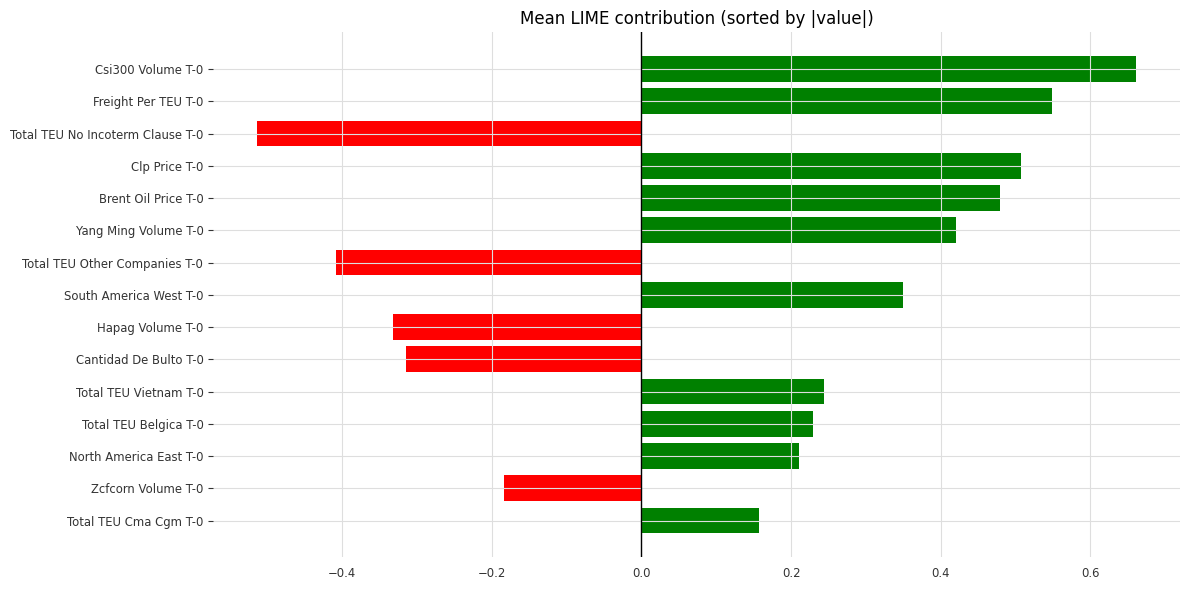

In [6]:
# ------------------------------------------------------------
# LIME stability analysis for ONE prediction (x0)
# ------------------------------------------------------------
#
# This LIME averages multiple runs to improve stability, while vanilla LIME uses a single random explanation.

# This Lime also disables discretaization to improve stability (because of the gaussian perturbations).

#flatten time series window



N = 20  # number of LIME runs to average
weights = []

for s in range(N):
    np.random.seed(1000 + s)
    exp = explainer.explain_instance(
        x0,
        predict_fn,
        num_features=20
    )
    weights.append(dict(exp.as_list()))

df_local_lime = pd.DataFrame(weights).fillna(0)

mean_importance = df_local_lime.mean().sort_values(ascending=False)
mean_importance.index = rename_specific(
    [prettify(n) for n in mean_importance.index]
)
std_importance = df_local_lime.std().sort_values(ascending=False)

print("Top mean LIME contributions:")
print(mean_importance.head(15))

print("\nTop unstable features (std):")
print(std_importance.head(15))

top_pos = mean_importance.sort_values(ascending=False).head(8)
top_neg = mean_importance.sort_values().head(8)

vals = mean_importance.copy()

# sort by absolute contribution
vals = vals.reindex(vals.abs().sort_values(ascending=False).index)

# keep top-k
vals = vals.head(15)
vals.index = rename_specific([prettify(n) for n in vals.index])
colors = ["green" if v > 0 else "red" for v in vals]

plt.figure(figsize=(12, 6))
plt.barh(vals.index, vals.values, color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.gca().invert_yaxis()
plt.title("Mean LIME contribution (sorted by |value|)")
plt.tight_layout()
# plt.savefig(
#     f"plots/local_lime_mean_abs_{target_col}_{test_size}.png",
#     dpi=200,
#     bbox_inches="tight"
# )
plt.show()


X_explain shape: (12, 3600)

Explaining origin 1/12 (end_idx=420)...

Explaining origin 2/12 (end_idx=421)...

Explaining origin 3/12 (end_idx=422)...

Explaining origin 4/12 (end_idx=423)...

Explaining origin 5/12 (end_idx=424)...

Explaining origin 6/12 (end_idx=425)...

Explaining origin 7/12 (end_idx=426)...

Explaining origin 8/12 (end_idx=427)...

Explaining origin 9/12 (end_idx=428)...

Explaining origin 10/12 (end_idx=429)...

Explaining origin 11/12 (end_idx=430)...

Explaining origin 12/12 (end_idx=431)...

Mean LIME surrogate fidelity (R^2) across runs: 0.9941022074183898

Top 30 flat features:
                             feature  importance_abs     signed  \
3579                    clp_price_t0       39.851732  39.851732   
3582                csi300_volume_t0       39.096248  38.845923   
3580                    cny_price_t0       35.081369 -35.081369   
3577              brent_oil_price_t0       31.961869  31.961869   
3542              SUM_TEU_ECUADOR_t0       20.87053

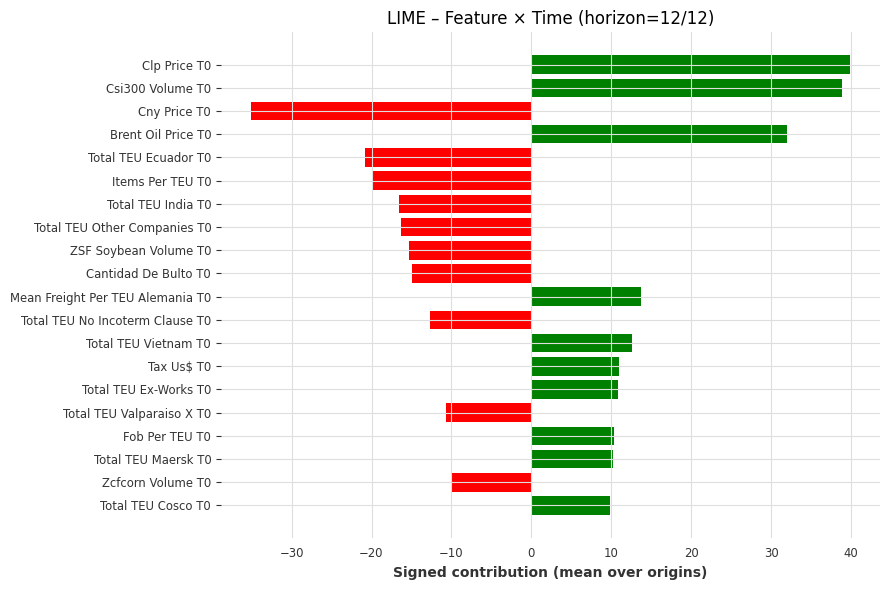

In [8]:
# ============================================================
# BUILD VALID WINDOWS + GLOBAL / AGGREGATED LIME (FIXED)
# ============================================================
#
# Key fixes vs original:
#   1) Uses VALID forecast origins only (no future leakage): end <= N_total - H - 1
#   2) Uses a LARGE background (X_bg) for stable feature statistics (std != ~0)
#   3) Forces LOCAL sampling around each instance (sample_around_instance=True)
#   4) Converts LIME coefficients -> per-instance contributions (coef * x_scaled)
#      so "signed" really means push up/down relative to the background mean.

from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Build MANY valid windows (no peeking into the future)
# ------------------------------------------------------------
cols_all = [target_col] + feature_cols
F = len(cols_all)
T = window_size
H = test_size

# Work directly in numpy (avoids any TimeSeries slicing surprises)
y_all = series_scaled.values(copy=True)   # (N_total, 1)
cov_all = cov_scaled.values(copy=True)    # (N_total, n_cov)
N_total = len(y_all)

end_min = T - 1
end_max = N_total - H - 1  # last origin with full H-step future available
assert end_max >= end_min, (
    f"Not enough data: need at least window_size={T} + horizon={H} points."
)

valid_ends = np.arange(end_min, end_max + 1)

# ------------------------------------------------------------
# 1) Windows to explain (keep your original intent: last H origins)
#    IMPORTANT: these are origins; the explained target time is end + HORIZON_TO_EXPLAIN + 1
# ------------------------------------------------------------
N_ORIGINS = min(test_size, len(valid_ends))  # you can increase this (e.g., 50-200) for smoother globals
ends_explain = valid_ends[-N_ORIGINS:]

X_explain = np.zeros((N_ORIGINS, T * F), dtype=float)
for i, end in enumerate(ends_explain):
    start = end - T + 1
    X_explain[i] = np.concatenate(
        [y_all[start:end + 1], cov_all[start:end + 1]],
        axis=1
    ).reshape(-1)

print("X_explain shape:", X_explain.shape)

# ------------------------------------------------------------
# 2) Background for LIME statistics (MUCH larger than N_ORIGINS)
# ------------------------------------------------------------
N_BACKGROUND = min(500, len(valid_ends))
rng = np.random.default_rng(seed)
bg_ends = rng.choice(valid_ends, size=N_BACKGROUND, replace=False)

X_bg = np.zeros((N_BACKGROUND, T * F), dtype=float)
for i, end in enumerate(bg_ends):
    start = end - T + 1
    X_bg[i] = np.concatenate(
        [y_all[start:end + 1], cov_all[start:end + 1]],
        axis=1
    ).reshape(-1)

# ------------------------------------------------------------
# 3) Feature names (must match flattening order!)
# ------------------------------------------------------------
feature_names = [
    f"{cols_all[j]}_t{T - 1 - t}"
    for t in range(T)
    for j in range(F)
]
feat_to_idx = {name: k for k, name in enumerate(feature_names)}
n_features = len(feature_names)

# ------------------------------------------------------------
# 4) LIME explainer
# ------------------------------------------------------------
explainer = LimeTabularExplainer(
    X_bg,
    feature_names=feature_names,
    mode="regression",
    verbose=False,
    discretize_continuous=False,
    sample_around_instance=True,  # <<< CRITICAL for "local" explanations with a global background
    random_state=seed,
)

# ------------------------------------------------------------
# 5) Aggregate LIME over origins (and repeats for stability)
# ------------------------------------------------------------
N_REPEATS = 10
NUM_SAMPLES = 5000  # explicit (LIME default), increase for more stability

agg_signed = np.zeros(n_features, dtype=float)
agg_abs = np.zeros(n_features, dtype=float)
scores = []

for i in range(N_ORIGINS):
    print(f"\nExplaining origin {i + 1}/{N_ORIGINS} (end_idx={int(ends_explain[i])})...")

    # scaled instance values used by LIME's surrogate model (when discretize_continuous=False)
    x_scaled = explainer.scaler.transform(X_explain[i].reshape(1, -1))[0]

    contrib_runs = []

    for s in range(N_REPEATS):
        # vary seed across both origin and repeat
        np.random.seed(1000 + i * 100 + s)

        exp_i = explainer.explain_instance(
            X_explain[i],
            predict_fn,
            num_features=n_features,
            num_samples=NUM_SAMPLES,
        )

        scores.append(getattr(exp_i, "score", np.nan))

        # exp_i.as_list() returns coefficients of the local linear surrogate
        coef_vec = np.zeros(n_features, dtype=float)
        for feat_name, w in exp_i.as_list():
            coef_vec[feat_to_idx[feat_name]] = w

        # Convert coefficients -> per-feature contribution at this instance:
        # contribution_j = coef_j * x_scaled_j
        contrib_runs.append(coef_vec * x_scaled)

    contrib_mean = np.mean(contrib_runs, axis=0)

    agg_signed += contrib_mean
    agg_abs += np.abs(contrib_mean)

agg_signed /= N_ORIGINS
agg_abs /= N_ORIGINS

print("\nMean LIME surrogate fidelity (R^2) across runs:", float(np.nanmean(scores)))

lime_summary = pd.DataFrame({
    "feature": feature_names,
    "importance_abs": agg_abs,
    "signed": agg_signed,
})
lime_summary["importance_pos"] = np.clip(lime_summary["signed"], 0, None)
lime_summary["importance_neg"] = np.clip(lime_summary["signed"], None, 0)

lime_summary = lime_summary.sort_values("importance_abs", ascending=False)

print("\nTop 30 flat features:")
print(lime_summary.head(30))

lime_summary["feature_pretty"] = rename_specific(
    [prettify(f) for f in lime_summary["feature"]]
)

# ------------------------------------------------------------
# 6) Plot: feature × time
# ------------------------------------------------------------
top = lime_summary.head(20)
colors = ["green" if v >= 0 else "red" for v in top["signed"]]

plt.figure(figsize=(9, 6))
plt.barh(top["feature_pretty"], top["signed"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Signed contribution (mean over origins)")
plt.title(f"LIME – Feature × Time (horizon={HORIZON_TO_EXPLAIN + 1}/{H})")
plt.tight_layout()

plt.savefig(
    f"plots/lime_feature_time_{target_col}_H{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


In [ ]:
# ------------------------------------------------------------
# 7) Aggregate over TIME → base feature
# ------------------------------------------------------------
lime_summary["base_feature"] = (
    lime_summary["feature"].str.rsplit("_t", n=1).str[0]
)

agg_feat = (
    lime_summary
    .groupby("base_feature", as_index=False)
    .agg(
        signed=("signed", "sum"),
        importance_abs=("importance_abs", "sum"),
    )
    .sort_values("importance_abs", ascending=False)
)

agg_feat["base_feature_pretty"] = rename_specific(
    [prettify(f) for f in agg_feat["base_feature"]]
)
topf = agg_feat.head(20)
colors = ["green" if v >= 0 else "red" for v in topf["signed"]]

plt.figure(figsize=(9, 6))
plt.barh(topf["base_feature_pretty"], topf["signed"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Signed contribution (aggregated over time)")
plt.title(f"LIME – Contributions by Feature (horizon={HORIZON_TO_EXPLAIN + 1}/{H})")
plt.tight_layout()

plt.savefig(
    f"plots/lime_feature_agg_{target_col}_H{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.close()
